In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from scipy.stats import linregress


In this notebook we go through all the graphs we used for the conclusion on the poster.

# Loading data

In [3]:
shape_area_manning = 6642 * 1_000_000  # 6642 km2

Obs = pd.read_csv(
    "./Data/5202080_Q_Day.Cmd.txt",
    delimiter=";",
    skiprows=36,
    header=0,
    encoding="cp1252",
    index_col=0,
    parse_dates=True
)
Obs.index.name = "Date"
Obs = Obs.rename(columns={" Value": "Q_m3s"})  # let op spatie in originele naam
Obs = Obs[Obs["Q_m3s"] != -999]
Obs["Q mm/d"] = Obs["Q_m3s"] * 86400 / shape_area_manning * 1000
Obs = Obs.loc["2014-01-01":"2025-12-31"]

# Load the potential evaporation data from MODIS
potevap_daily_df = pd.read_csv('./Data/manning_MODIS_potevap_8days.csv') # 0.1 mm/8days
potevap_daily_df['date'] = pd.to_datetime(potevap_daily_df['system:index'], format='%Y_%m_%d')
potevap_daily_df.set_index('date', inplace=True)
potevap_daily_df.drop(columns=['system:index'], inplace=True)
potevap_daily_df['PE'] = potevap_daily_df['PET'] * 0.1  # mm/8days
potevap_daily_df['PE mm/d'] = potevap_daily_df['PE'] / 8   #mm/day

#acutal evaporation from ERA5
evap_daily = pd.read_csv("./Data/manning_ERA5_evap_daily.csv")
evap_daily["Date"] = pd.to_datetime(evap_daily["system:index"], format="%Y%m%d")
evap_daily = evap_daily.set_index("Date")[["total_evaporation_sum"]].rename(
    columns={"total_evaporation_sum": "AEP mm/d"}
)
evap_daily["AEP mm/d"] = evap_daily["AEP mm/d"].abs() * 1000

precip_daily = pd.read_csv("./Data/manning_ERA5_precip_daily.csv")
precip_daily["Date"] = pd.to_datetime(precip_daily["system:index"], format="%Y%m%d")
precip_daily = precip_daily.set_index("Date")[["total_precipitation_sum"]].rename(
    columns={"total_precipitation_sum": "P mm/d"}
)

precip_daily["P mm/d"] = precip_daily["P mm/d"] * 1000

Obs = pd.read_csv(
    "./Data/5202080_Q_Day.Cmd.txt",
    delimiter=";",
    skiprows=36,
    header=0,
    encoding="cp1252",
    index_col=0,
    parse_dates=True
)
Obs.index.name = "Date"
Obs = Obs.rename(columns={" Value": "Q_m3s"})  # let op spatie in originele naam
Obs = Obs[Obs["Q_m3s"] != -999]
Obs["Q mm/d"] = Obs["Q_m3s"] * 86400 / shape_area_manning * 1000
Obs = Obs.loc["2014-01-01":"2025-12-31"]


df_daily = pd.concat(
    [
        precip_daily[["P mm/d"]],
        potevap_daily_df[["PE mm/d"]],
        evap_daily[["AEP mm/d"]],
        Obs[["Q mm/d"]]
    ],
    axis=1
).dropna()

df_daily.index = pd.to_datetime(df_daily.index)


df_monthly = pd.DataFrame()
df_monthly["P_mm"] = df_daily["P mm/d"].resample("MS").sum()
df_monthly["PE_mm"] = df_daily["PE mm/d"].resample("MS").sum()
df_monthly["AEP_mm"] = df_daily["AEP mm/d"].resample("MS").sum()
df_monthly["Q_mm"] = df_daily["Q mm/d"].resample("MS").sum()

df_monthly = df_monthly.dropna()






# Discharge before and after bush fire 2019 - 2020

Mean discharge pre : 0.6694027100271004
Mean discharge post: 2.929182637453493
Difference (post - pre): 2.2597799274263926


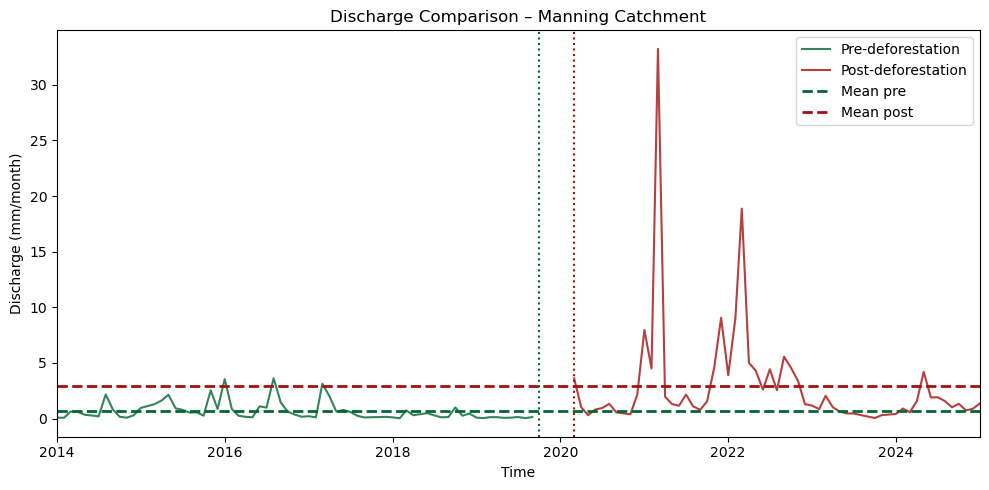

In [4]:
q_pre = df_monthly[(df_monthly.index >= "2014-01-01") & 
                   (df_monthly.index < "2019-10-01")]["Q_mm"]

q_post = df_monthly[(df_monthly.index >= "2020-03-01") & 
                    (df_monthly.index <= "2025-01-01")]["Q_mm"]


mean_pre = q_pre.mean()
mean_post = q_post.mean()

print("Mean discharge pre :", mean_pre)
print("Mean discharge post:", mean_post)
print("Difference (post - pre):", mean_post - mean_pre)

plt.figure(figsize=(10,5))

# Time series
plt.plot(q_pre.index, q_pre, color="#006633", alpha=0.8, label="Pre-deforestation")
plt.plot(q_post.index, q_post, color="#a31010", alpha=0.8, label="Post-deforestation")
# Mean lines
plt.axhline(mean_pre, color="#006633", linestyle="--", linewidth=2, label="Mean pre")
plt.axhline(mean_post, color="#a31010", linestyle="--", linewidth=2, label="Mean post")
# Event lines
plt.axvline(pd.Timestamp("2019-10-01"), linestyle=':', color='#006633')
plt.axvline(pd.Timestamp("2020-03-01"), linestyle=':', color='#a31010')
plt.title("Discharge Comparison – Manning Catchment")
plt.xlabel("Time")
plt.ylabel("Discharge (mm/month)")
plt.xlim(pd.Timestamp("2014-01-01"), pd.Timestamp("2025-01-01"))
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\laura\AppData\Local\Temp\ipykernel_28448\3355289111.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([q_pre, q_post],


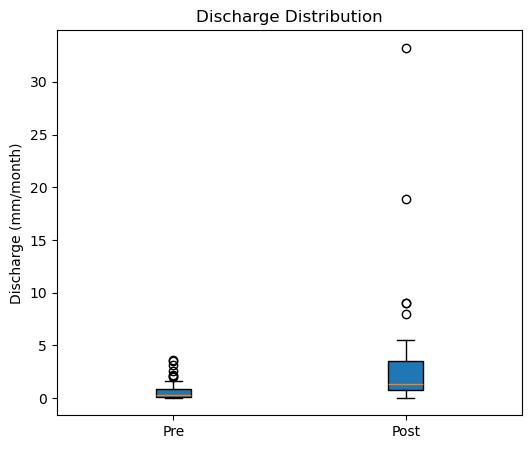

In [5]:
plt.figure(figsize=(6,5))

plt.boxplot([q_pre, q_post],
            labels=["Pre", "Post"],
            patch_artist=True)

plt.title("Discharge Distribution")
plt.ylabel("Discharge (mm/month)")

plt.show()

# Runoff coefficient

Mean RC pre-deforestation/fire period  : 0.12714976536458314
Mean RC during deforestation/fire period: 0.33166380099927956
Mean RC post-deforestation/fire period : 0.5176628911291666


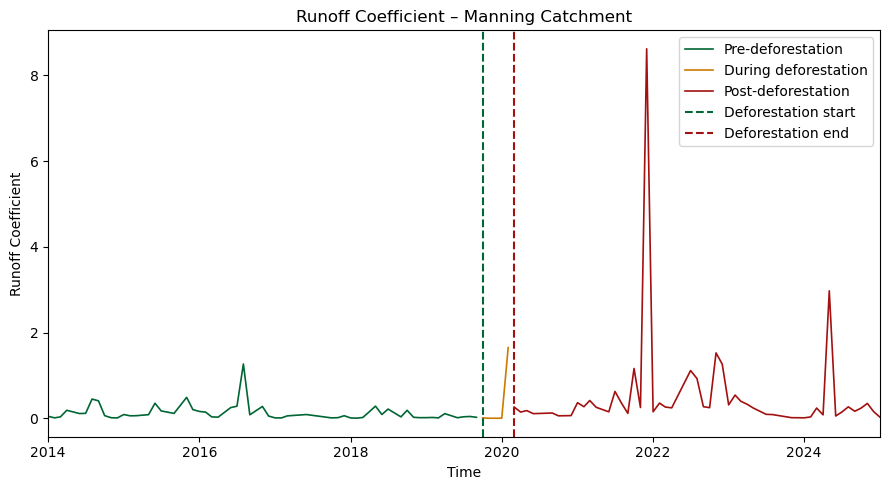


Highest RC values:
                 P_mm      PE_mm     AEP_mm       Q_mm        RC
2021-12-01   1.051226  19.690152  12.414824   9.063272  8.621623
2024-05-01   1.412774   5.928044   4.238850   4.201938  2.974247
2020-02-01  13.942705  20.454580  15.401456  22.973359  1.647697
2022-11-01   2.213377  26.672116  14.899823   3.376429  1.525465
2016-08-01   2.868848  10.654347   7.876568   3.632950  1.266344
2022-12-01   1.031041  24.742642  13.120018   1.301190  1.262016
2021-10-01   1.336829  16.165995   8.987368   1.552260  1.161151
2022-07-01   3.985967   6.238313   4.845685   4.437203  1.113206
2022-08-01   2.749606   9.497174   7.176082   2.548345  0.926804
2025-03-01  29.820735  16.283747  14.493661  19.344807  0.648703


In [6]:
# Runoff coefficient
df_monthly["RC"] = df_monthly["Q_mm"] / df_monthly["P_mm"]

# optional: remove impossible / unstable values when P is near zero
# you can comment this out if you want to keep everything
df_monthly = df_monthly[df_monthly["P_mm"] > 1]

pre_start = "2014-01-01"
pre_end   = "2019-10-01"

during_start = "2019-10-01"
during_end   = "2020-03-01"

post_start = "2020-03-01"
post_end   = "2025-01-01"

rc_pre = df_monthly[(df_monthly.index >= pre_start) & (df_monthly.index < during_start)].copy()
rc_during = df_monthly[(df_monthly.index >= during_start) & (df_monthly.index < post_start)].copy()
rc_post = df_monthly[(df_monthly.index >= post_start) & (df_monthly.index <= post_end)].copy()


print("Mean RC pre-deforestation/fire period  :", rc_pre["RC"].mean())
print("Mean RC during deforestation/fire period:", rc_during["RC"].mean())
print("Mean RC post-deforestation/fire period :", rc_post["RC"].mean())


plt.figure(figsize=(9, 5))

plt.plot(rc_pre.index, rc_pre["RC"], color="#006633", linewidth=1.2, label="Pre-deforestation")
plt.plot(rc_during.index, rc_during["RC"], color="#cc7a00", linewidth=1.2, label="During deforestation")
plt.plot(rc_post.index, rc_post["RC"], color="#a31010", linewidth=1.2, label="Post-deforestation")

plt.axvline(pd.Timestamp(during_start), linestyle="--", color="#006633", linewidth=1.5, label="Deforestation start")
plt.axvline(pd.Timestamp(post_start), linestyle="--", color="#a31010", linewidth=1.5, label="Deforestation end")

plt.title("Runoff Coefficient – Manning Catchment")
plt.xlabel("Time")
plt.ylabel("Runoff Coefficient")
plt.xlim(pd.Timestamp("2014-01-01"), pd.Timestamp("2025-01-01"))
plt.legend()
plt.tight_layout()
plt.show()


print("\nHighest RC values:")
print(df_monthly.sort_values("RC", ascending=False).head(10))


df_monthly.to_csv("./Data/manning_runoff_coefficient_monthly.csv")

In [7]:
perc_change = (mean_post - mean_pre) / mean_pre * 100
print("Percentage change:", perc_change, "%")

Percentage change: 337.5815325478599 %


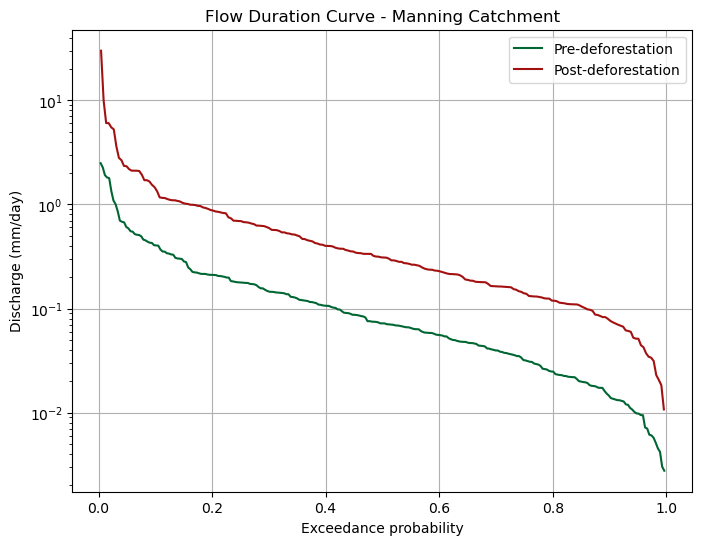

In [8]:
def flow_duration_curve(Q):
    Q_sorted = np.sort(Q)[::-1]  # van hoog naar laag
    N = len(Q_sorted)
    exceedance = np.arange(1, N + 1) / (N + 1)
    return exceedance, Q_sorted

# Daily discharge in mm/day voor pre en post
q_pre = df_daily.loc[pre_start:pre_end, "Q mm/d"].dropna()
q_post = df_daily.loc[post_start:post_end, "Q mm/d"].dropna()

# FDC berekenen
exceedance_pre, Q_sorted_pre = flow_duration_curve(q_pre)
exceedance_post, Q_sorted_post = flow_duration_curve(q_post)

# Plot
plt.figure(figsize=(8,6))
plt.plot(exceedance_pre, Q_sorted_pre, label="Pre-deforestation", color="#006633")
plt.plot(exceedance_post, Q_sorted_post, label="Post-deforestation", color="#a31010")

plt.yscale("log")
plt.xlabel("Exceedance probability")
plt.ylabel("Discharge (mm/day)")
plt.title("Flow Duration Curve - Manning Catchment")
plt.grid(True)
plt.legend()

# Checking if there is a trend in precip and/or evap

ERA5: increasing trend
  slope per month = 0.2204 mm/month
  p-value = 0.1078

CHIRPS: increasing trend
  slope per month = 0.1792 mm/month
  p-value = 0.1864

IMERG: increasing trend
  slope per month = 0.3306 mm/month
  p-value = 0.0361



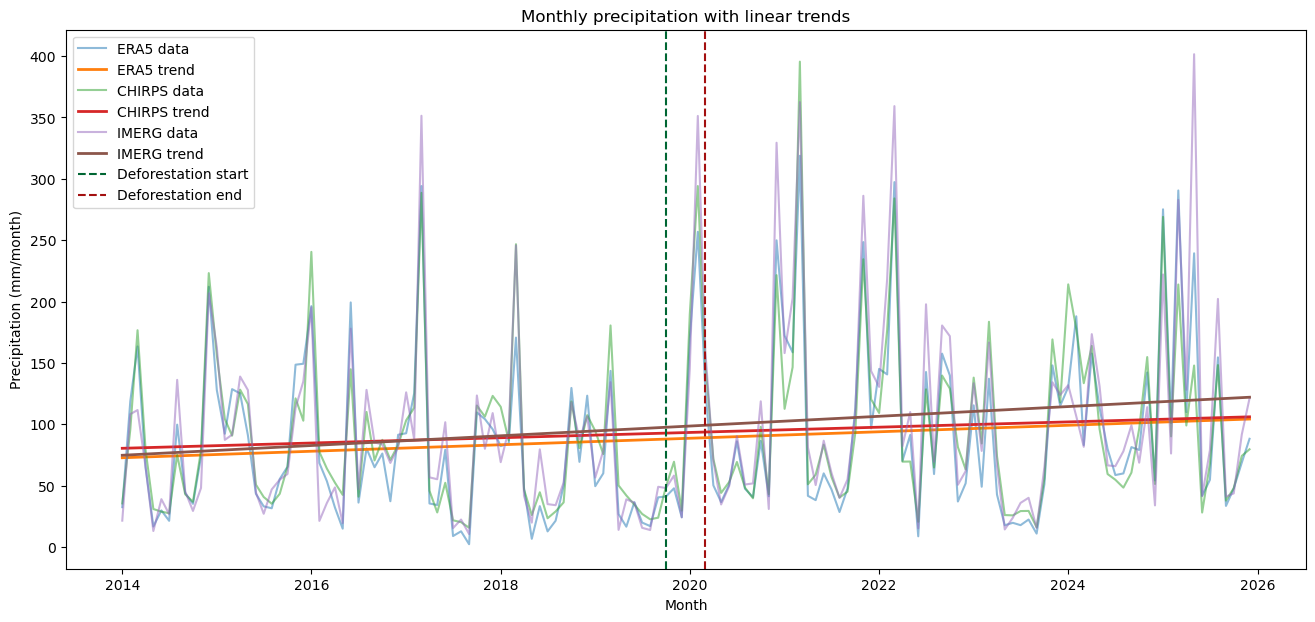

In [9]:
era5P = pd.read_csv('./Data/manning_ERA5_precip_daily.csv')      # m/day
chirps = pd.read_csv('./Data/manning_chirps_precip_daily.csv')   # mm/day
imerg = pd.read_csv('./Data/manning_IMERG_precip_hourly.csv')    # mm/hr
era5P['date'] = pd.to_datetime(era5P['system:index'], format='%Y%m%d')
era5P = era5P.set_index('date')
era5P = era5P.drop(columns=['system:index'])
era5P['total_precipitation_sum'] = era5P['total_precipitation_sum'] * 1000  # m/day -> mm/day
era5P_monthly = era5P.resample('MS').sum()
chirps['date'] = pd.to_datetime(chirps['system:index'], format='%Y%m%d')
chirps = chirps.set_index('date')
chirps = chirps.drop(columns=['system:index'])
chirps_monthly = chirps.resample('MS').sum()

imerg['date'] = pd.to_datetime(imerg['system:index'], format='%Y%m%d%H%M%S')
imerg = imerg.set_index('date')
imerg = imerg.drop(columns=['system:index'])


imerg = imerg.resample('D').sum() / 2
imerg_monthly = imerg.resample('MS').sum()

start_date = '2014-01-01'
end_date = '2025-12-31'

era5P_monthly = era5P_monthly.loc[start_date:end_date]
chirps_monthly = chirps_monthly.loc[start_date:end_date]
imerg_monthly = imerg_monthly.loc[start_date:end_date]

P_df = pd.DataFrame({
    'ERA5': era5P_monthly['total_precipitation_sum'],
    'CHIRPS': chirps_monthly['precipitation'],
    'IMERG': imerg_monthly['precipitation']
})

P_df = P_df.dropna()

plt.figure(figsize=(16, 7))

for col in P_df.columns:
    y = P_df[col].values
    x = np.arange(len(y))

    # linear regression
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    trend_line = intercept + slope * x

    plt.plot(P_df.index, y, label=f'{col} data', alpha=0.5)
    plt.plot(P_df.index, trend_line, linewidth=2, label=f'{col} trend')

    if slope > 0:
        direction = 'increasing trend'
    elif slope < 0:
        direction = 'decreasing trend'
    else:
        direction = 'no trend'

    print(f'{col}: {direction}')
    print(f'  slope per month = {slope:.4f} mm/month')
    print(f'  p-value = {p_value:.4f}')
    print('')
plt.axvline(pd.Timestamp(during_start), linestyle="--", color="#006633", linewidth=1.5, label="Deforestation start")
plt.axvline(pd.Timestamp(post_start), linestyle="--", color="#a31010", linewidth=1.5, label="Deforestation end")
plt.legend()
plt.xlabel('Month')
plt.ylabel('Precipitation (mm/month)')
plt.title('Monthly precipitation with linear trends')
plt.show()

All precipitation datasets show a slight increasing trend over time. However, only the IMERG dataset shows a statistically significant increase (p < 0.05), while ERA5 and CHIRPS do not. This suggests that there is no consistent evidence for a strong increase in precipitation across datasets.

Because precipitation is the primary driver of discharge, this inconsistency implies that observed changes in river discharge cannot be confidently attributed to changes in rainfall alone. Therefore, other factors, such as deforestation and changes in catchment storage and evapotranspiration, are likely contributing to changes in discharge.

Pre period:  2014-01-01 to 2019-10-01  | n = 70 months
Post period: 2020-03-01 to 2025-01-01 | n = 59 months
Threshold used in design-life plot: 159.6 mm/month
Monthly exceedance probability pre:  0.086
Monthly exceedance probability post: 0.119


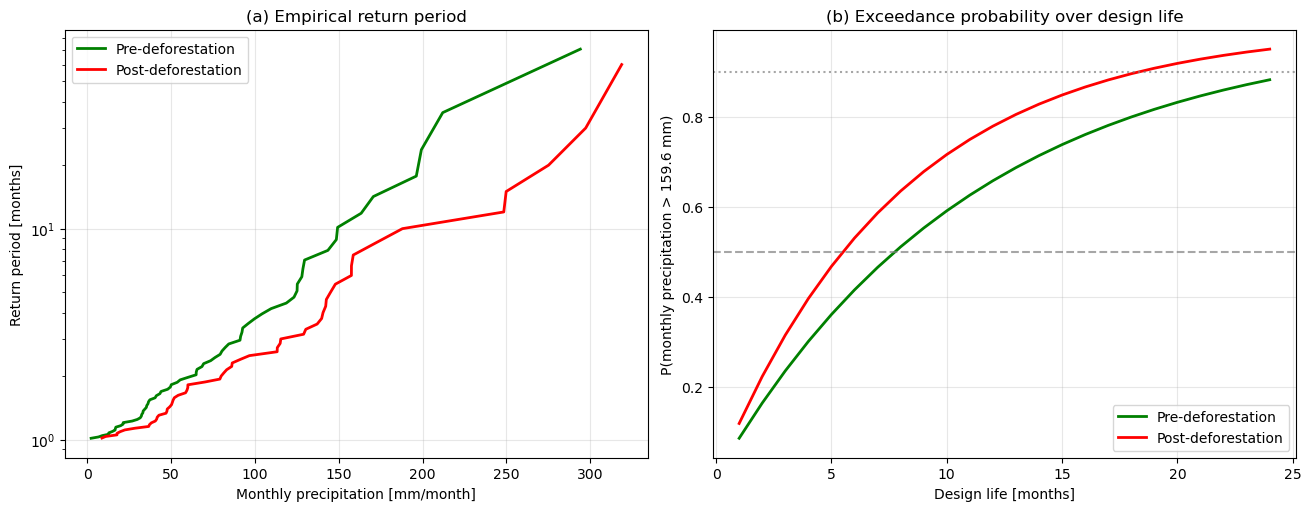

In [18]:
#extreme values check

P_month = P_df["ERA5"].dropna()
P_month.index = pd.to_datetime(P_month.index)

pre = P_month.loc["2014-01-01":"2019-10-01"].copy()
post = P_month.loc["2020-03-01":"2025-01-01"].copy()

def empirical_return_curve(series):
    x = np.sort(series.values)[::-1]            # descending
    n = len(x)
    rank = np.arange(1, n + 1)
    p_exceed = rank / (n + 1)                   # exceedance probability per month
    T_months = 1 / p_exceed                     # return period in months
    return x, T_months

x_pre, T_pre = empirical_return_curve(pre)
x_post, T_post = empirical_return_curve(post)
threshold = np.quantile(pd.concat([pre, post]), 0.90)
p_pre = np.mean(pre > threshold)
p_post = np.mean(post > threshold)
design_life = np.arange(1, 25)  
Pexc_pre = 1 - (1 - p_pre) ** design_life
Pexc_post = 1 - (1 - p_post) ** design_life
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

#return period
axes[0].plot(x_pre, T_pre, color="green", linewidth=2, label="Pre-deforestation")
axes[0].plot(x_post, T_post, color="red", linewidth=2, label="Post-deforestation")
axes[0].set_yscale("log")
axes[0].set_xlabel("Monthly precipitation [mm/month]")
axes[0].set_ylabel("Return period [months]")
axes[0].set_title("(a) Empirical return period")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

#Design life exceedance probability
axes[1].plot(design_life, Pexc_pre, color="green", linewidth=2, label="Pre-deforestation")
axes[1].plot(design_life, Pexc_post, color="red", linewidth=2, label="Post-deforestation")
axes[1].axhline(0.5, color="grey", linestyle="--", alpha=0.7)
axes[1].axhline(0.9, color="grey", linestyle=":", alpha=0.7)
axes[1].set_xlabel("Design life [months]")
axes[1].set_ylabel(f"P(monthly precipitation > {threshold:.1f} mm)")
axes[1].set_title("(b) Exceedance probability over design life")
axes[1].grid(True, alpha=0.3)
axes[1].legend()
print(f"Pre period:  {pre.index.min().date()} to {pre.index.max().date()}  | n = {len(pre)} months")
print(f"Post period: {post.index.min().date()} to {post.index.max().date()} | n = {len(post)} months")
print(f"Threshold used in design-life plot: {threshold:.1f} mm/month")
print(f"Monthly exceedance probability pre:  {p_pre:.3f}")
print(f"Monthly exceedance probability post: {p_post:.3f}")



In the model, ERA5 is used 

GLDAS: increasing trend
  slope per month = 0.1365 mm/month
  p-value = 0.0520

ERA5: increasing trend
  slope per month = 0.0511 mm/month
  p-value = 0.3622

MOD16: increasing trend
  slope per month = 0.0288 mm/month
  p-value = 0.6757

CMRSET: increasing trend
  slope per month = 0.0624 mm/month
  p-value = 0.2222



Text(0.5, 1.0, 'Monthly evaporation with linear trends')

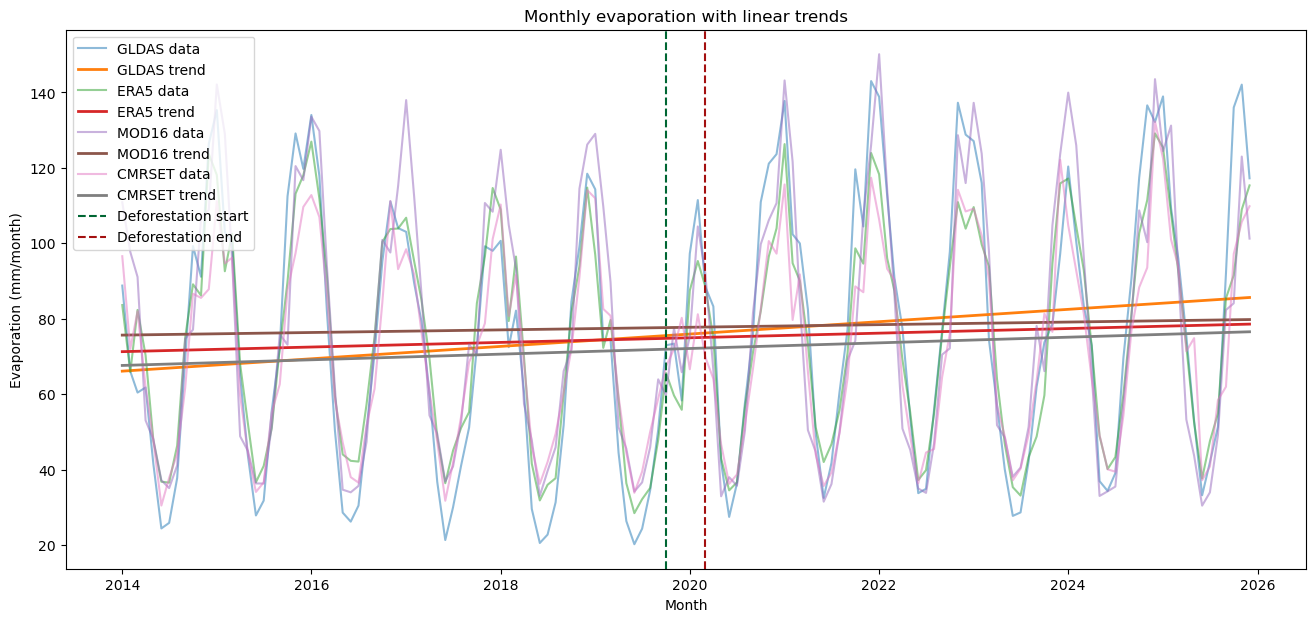

In [11]:
gldas = pd.read_csv('./Data/manning_gldas_evap_3hour.csv') # mm/s
era5E = pd.read_csv('./Data/manning_ERA5_evap_daily.csv') # m/day
mod16 = pd.read_csv('./Data/manning_mod16_evap_8day.csv') # 0.1 mm/8days
CMRSET = pd.read_csv('./Data/manning_CMRSETlandsat_evap_monthly.csv') # mm/month

# Setting the units to mm/month
gldas['date'] = pd.to_datetime(gldas['system:index'], format='A%Y%m%d_%H%M')
gldas.set_index('date', inplace=True)
gldas.drop(columns=['system:index'], inplace=True)
gldas['Evap_tavg'] = gldas['Evap_tavg'] * 10800 # mm/3hr
gldas = gldas.resample('D').sum() # mm/day
gldas_monthly = gldas.resample('MS').sum() # mm/month

era5E['date'] = pd.to_datetime(era5E['system:index'], format='%Y%m%d')
era5E.set_index('date', inplace=True)
era5E.drop(columns=['system:index'], inplace=True)
era5E['total_evaporation_sum'] = era5E['total_evaporation_sum'] * -1000 # mm/day
era5E_monthly = era5E.resample('MS').sum() # mm/month

mod16['date'] = pd.to_datetime(mod16['system:index'], format='%Y_%m_%d')
mod16.set_index('date', inplace=True)
mod16.drop(columns=['system:index'], inplace=True)
mod16['ET'] = mod16['ET'] * 0.1 # mm/8days
mod16_monthly = mod16.resample('MS').sum() # mm/month

CMRSET['date'] = pd.to_datetime(CMRSET['system:index'], format='%Y_%m_%d')
CMRSET.set_index('date', inplace=True)
CMRSET.drop(columns=['system:index'], inplace=True)
CMRSET['ETa_monthly'] = CMRSET['ETa'] * CMRSET.index.days_in_month

CMRSET_monthly = CMRSET.copy()

start_date = '2014-01-01'
end_date = '2025-12-31'

gldas_monthly = gldas_monthly.loc[start_date:end_date]
era5E_monthly = era5E_monthly.loc[start_date:end_date]
mod16_monthly = mod16_monthly.loc[start_date:end_date]
CMRSET_monthly = CMRSET_monthly.loc[start_date:end_date]

E_df = pd.DataFrame({
    'GLDAS': gldas_monthly['Evap_tavg'],
    'ERA5': era5E_monthly['total_evaporation_sum'],
    'MOD16': mod16_monthly['ET'],
    'CMRSET': CMRSET_monthly['ETa_monthly']
})

E_df = E_df.dropna()
plt.figure(figsize=(16, 7))

for col in E_df.columns:
    y = E_df[col].values
    x = np.arange(len(y))

    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    trend_line = intercept + slope * x

    plt.plot(E_df.index, y, label=f'{col} data', alpha=0.5)
    plt.plot(E_df.index, trend_line, linewidth=2, label=f'{col} trend')

    if slope > 0:
        direction = 'increasing trend'
    elif slope < 0:
        direction = 'decreasing trend'
    else:
        direction = 'no trend'

    print(f'{col}: {direction}')
    print(f'  slope per month = {slope:.4f} mm/month')
    print(f'  p-value = {p_value:.4f}')
    print('')

plt.axvline(pd.Timestamp(during_start), linestyle="--", color="#006633", linewidth=1.5, label="Deforestation start")
plt.axvline(pd.Timestamp(post_start), linestyle="--", color="#a31010", linewidth=1.5, label="Deforestation end")

plt.legend()
plt.xlabel('Month')
plt.ylabel('Evaporation (mm/month)')
plt.title('Monthly evaporation with linear trends')


All evaporation datasets show strong seasonal variability but no clear or consistent long-term trend. The slopes of the linear regressions are small and not statistically significant across datasets.

This indicates that atmospheric demand (evaporation) has remained relatively stable over time. As a result, changes in river discharge are unlikely to be driven by changes in evaporation. Combined with the weak and inconsistent precipitation trends, this suggests that observed changes in discharge are more likely caused by land-use changes, such as deforestation, which alter interception, soil storage, and runoff processes.

Rootzone storage

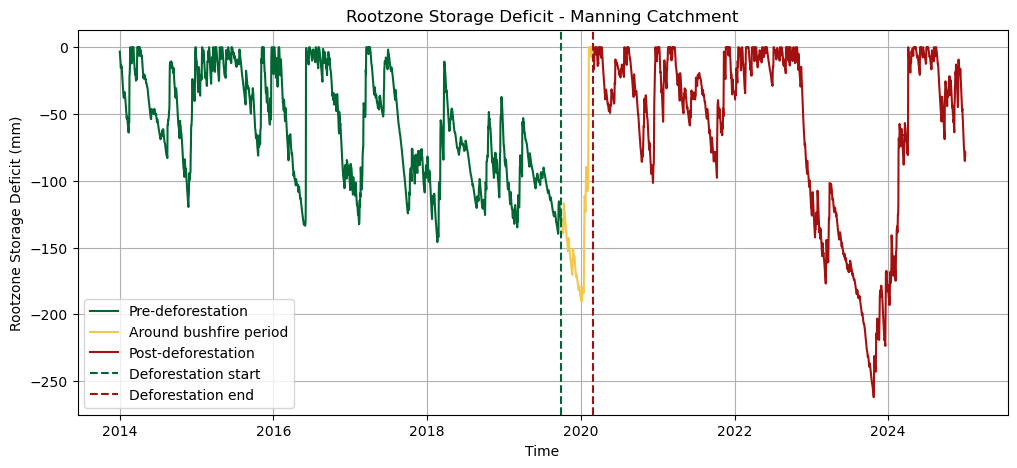

In [12]:
data = pd.concat(
    [
        precip_daily[["P mm/d"]],
        evap_daily[["AEP mm/d"]],
        Obs[["Q mm/d"]]
    ],
    axis=1
).dropna()
data.index = pd.to_datetime(data.index)

data.index = pd.to_datetime(data.index)
full_period = data.loc["2014-01-01":"2025-01-01"].copy()
AE_LT_full = full_period["P mm/d"].mean() - full_period["Q mm/d"].mean()
AE_full = full_period["AEP mm/d"] * (AE_LT_full / full_period["AEP mm/d"].mean())
# Rootzone storage deficit 
SD_full = np.zeros(len(full_period))
for i in range(len(full_period)):
    if i == 0:
        SD_full[i] = min(
            0,
            full_period["P mm/d"].iloc[i] - AE_full.iloc[i]
        )
    else:
        SD_full[i] = min(
            0,
            SD_full[i-1] + full_period["P mm/d"].iloc[i] - AE_full.iloc[i]
        )

df2_full = pd.DataFrame(index=full_period.index)
df2_full["AE_full"] = AE_full
df2_full["SD_full"] = SD_full
pre_mask = (
    (df2_full.index >= pd.Timestamp("2014-01-01")) &
    (df2_full.index <= pd.Timestamp(pre_end))
)
mid_mask = (
    (df2_full.index > pd.Timestamp(pre_end)) &
    (df2_full.index < pd.Timestamp(post_start))
)
post_mask = (
    (df2_full.index >= pd.Timestamp(post_start)) &
    (df2_full.index <= pd.Timestamp("2025-01-01"))
)

plt.figure(figsize=(12, 5))
plt.plot(
    df2_full.index[pre_mask],
    df2_full.loc[pre_mask, "SD_full"],
    label="Pre-deforestation",
    color="#006633"
)
plt.plot(
    df2_full.index[mid_mask],
    df2_full.loc[mid_mask, "SD_full"],
    label="Around bushfire period",
    color="#f2c94c"
)
plt.plot(
    df2_full.index[post_mask],
    df2_full.loc[post_mask, "SD_full"],
    label="Post-deforestation",
    color="#a31010"
)
plt.axvline(pd.Timestamp(pre_end), linestyle='--', color='#006633', label='Deforestation start')
plt.axvline(pd.Timestamp(post_start), linestyle='--', color='#a31010', label='Deforestation end')
plt.title("Rootzone Storage Deficit - Manning Catchment")
plt.ylabel("Rootzone Storage Deficit (mm)")
plt.xlabel("Time")
plt.legend()
plt.grid(True)
plt.show()

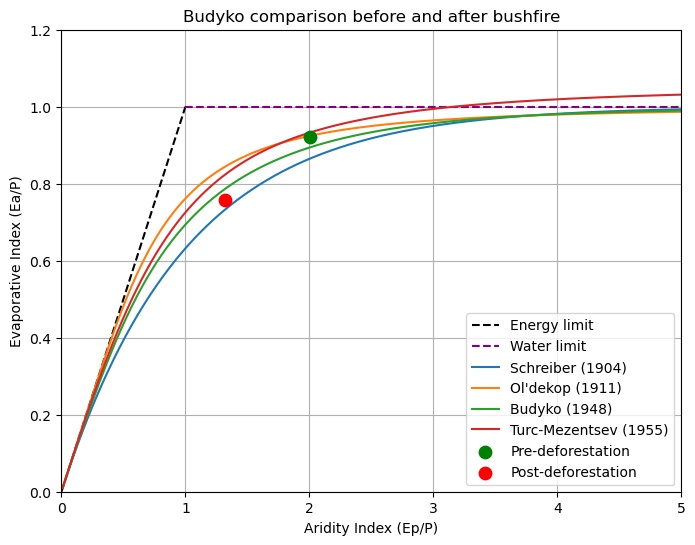

In [13]:
budyko_data = pd.concat(
    [
        precip_daily[["P mm/d"]],
        potevap_daily_df[["PE mm/d"]],   # potential evaporation
        Obs[["Q mm/d"]]
    ],
    axis=1
).dropna()

budyko_data.index = pd.to_datetime(budyko_data.index)

c_pre_deforestation = budyko_data.loc["2014-01-01":pre_end].copy()
c_post_deforestation = budyko_data.loc[post_start:"2025-01-01"].copy()

# actual evaporation as P - Q
c_pre_deforestation["AEP mm/d"] = (
    c_pre_deforestation["P mm/d"] - c_pre_deforestation["Q mm/d"]
)
c_post_deforestation["AEP mm/d"] = (
    c_post_deforestation["P mm/d"] - c_post_deforestation["Q mm/d"]
)
# long-term means
P_pre = c_pre_deforestation["P mm/d"].mean()
PE_pre = c_pre_deforestation["PE mm/d"].mean()
AEP_pre = c_pre_deforestation["AEP mm/d"].mean()

P_post = c_post_deforestation["P mm/d"].mean()
PE_post = c_post_deforestation["PE mm/d"].mean()
AEP_post = c_post_deforestation["AEP mm/d"].mean()

AI_pre = PE_pre / P_pre      # Aridity Index = Ep/P
EI_pre = AEP_pre / P_pre     # Evaporative Index = Ea/P

AI_post = PE_post / P_post
EI_post = AEP_post / P_post

phi = np.linspace(0.01, 5, 500)
EaP_schreiber = 1 - np.exp(-phi)
EaP_oldekop = phi * np.tanh(1 / phi)
EaP_budyko = np.sqrt(phi * np.tanh(1 / phi) * (1 - np.exp(-phi)))
EaP_turc = 1 / np.sqrt(0.9 + (1 / phi)**2)
plt.figure(figsize=(8, 6))
plt.xlim(0, 5)
plt.ylim(0, 1.2)
phi_energy = np.linspace(0, 1, 200)
plt.plot(phi_energy, phi_energy, 'k--', label='Energy limit')
plt.hlines(1, 1, 5, colors='purple', linestyles='--', label='Water limit')
plt.plot(phi, EaP_schreiber, label='Schreiber (1904)')
plt.plot(phi, EaP_oldekop, label="Ol'dekop (1911)")
plt.plot(phi, EaP_budyko, label='Budyko (1948)')
plt.plot(phi, EaP_turc, label='Turc-Mezentsev (1955)')
plt.scatter(AI_pre, EI_pre, color='green', s=80, label='Pre-deforestation', zorder=5)
plt.scatter(AI_post, EI_post, color='red', s=80, label='Post-deforestation', zorder=5)
plt.xlabel("Aridity Index (Ep/P)")
plt.ylabel("Evaporative Index (Ea/P)")
plt.title("Budyko comparison before and after bushfire")
plt.legend()
plt.grid(True)
plt.show()

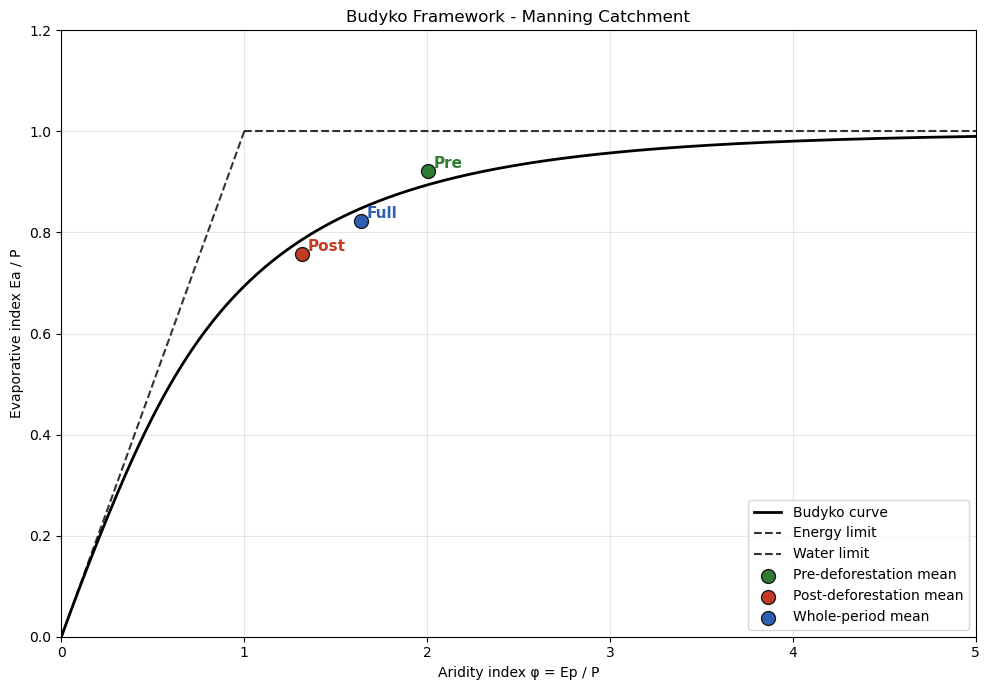

In [14]:
c_full = budyko_data.loc["2014-01-01":"2025-01-01"].copy()
c_full["AEP mm/d"] = c_full["P mm/d"] - c_full["Q mm/d"]
P_full = c_full["P mm/d"].mean()
PE_full = c_full["PE mm/d"].mean()
AEP_full = c_full["AEP mm/d"].mean()
P_pre = c_pre_deforestation["P mm/d"].mean()
PE_pre = c_pre_deforestation["PE mm/d"].mean()
AEP_pre = c_pre_deforestation["AEP mm/d"].mean()

P_post = c_post_deforestation["P mm/d"].mean()
PE_post = c_post_deforestation["PE mm/d"].mean()
AEP_post = c_post_deforestation["AEP mm/d"].mean()
AI_pre = PE_pre / P_pre
EI_pre = AEP_pre / P_pre
AI_post = PE_post / P_post
EI_post = AEP_post / P_post
AI_full = PE_full / P_full
EI_full = AEP_full / P_full
phi = np.linspace(0.001, 5, 500)
EaP_budyko = np.sqrt(phi * np.tanh(1 / phi) * (1 - np.exp(-phi)))
fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(phi, EaP_budyko, color="black", linewidth=2, label="Budyko curve")
# Energy limit
phi_energy = np.linspace(0, 1, 200)
ax.plot(
    phi_energy, phi_energy,
    linestyle="--", color="black", alpha=0.8,
    label="Energy limit")
# Water limit
ax.hlines(
    1, 1, 5,
    colors="black", linestyles="--", alpha=0.8,
    label="Water limit")
# Points
ax.scatter(
    AI_pre, EI_pre,
    s=100, color="#2e7d32", edgecolor="#1b1b1b", zorder=5,
    label="Pre-deforestation mean")
ax.scatter(
    AI_post, EI_post,
    s=100, color="#c23b22", edgecolor="#1b1b1b", zorder=5,
    label="Post-deforestation mean")
ax.scatter(
    AI_full, EI_full,
    s=100, color="#2f5fb3", edgecolor="#1b1b1b", zorder=5,
    label="Whole-period mean")

ax.text(AI_pre + 0.03, EI_pre + 0.005, "Pre",
        color="#2e7d32", fontsize=11, weight="bold")
ax.text(AI_post + 0.03, EI_post + 0.005, "Post",
        color="#c23b22", fontsize=11, weight="bold")
ax.text(AI_full + 0.03, EI_full + 0.005, "Full",
        color="#2f5fb3", fontsize=11, weight="bold")
ax.set_xlim(0, 5)
ax.set_ylim(0, 1.2)
ax.set_xlabel("Aridity index φ = Ep / P")
ax.set_ylabel("Evaporative index Ea / P")
ax.set_title("Budyko Framework - Manning Catchment")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right", frameon=True, fontsize=10)
plt.tight_layout()
plt.show()